Final - neuralt netværk

In [11]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import importlib_resources
import matplotlib.pyplot as plt
import torch
from scipy import stats
from scipy.io import loadmat
from sklearn import model_selection
from dtuimldmtools import draw_neural_net, train_neural_net
import pandas as pd

In [12]:
# Load csv file with data
df = pd.read_csv('null-corrected.csv')
df = df.drop(columns='index')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [13]:
df = pd.get_dummies(df, columns=['cp', 'thal', 'restecg', 'slope'], drop_first=True, dtype=float)
df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,num,cp_2.0,cp_3.0,cp_4.0,thal_3.0,thal_6.0,thal_7.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,110.0,264.0,0.0,132.0,0.0,1.2,0.0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
299,68.0,1.0,144.0,193.0,1.0,141.0,0.0,3.4,2.0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300,57.0,1.0,130.0,131.0,0.0,115.0,1.0,1.2,1.0,3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
301,57.0,0.0,130.0,236.0,0.0,174.0,0.0,0.0,1.0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [14]:
X = df.to_numpy()
y = df['num'].to_numpy() 
X

array([[ 63.,   1., 145., ...,   1.,   0.,   1.],
       [ 67.,   1., 160., ...,   1.,   1.,   0.],
       [ 67.,   1., 120., ...,   1.,   1.,   0.],
       ...,
       [ 57.,   1., 130., ...,   0.,   1.,   0.],
       [ 57.,   0., 130., ...,   1.,   1.,   0.],
       [ 38.,   1., 138., ...,   0.,   0.,   0.]], shape=(303, 20))

In [22]:
# Standardisering af data - træk middelværdi fra og divider med standardafvigelse
N = len(X)
X_ = X - np.ones((N, 1)) * X.mean(axis=0)
X_scaled = X_ / X.std(axis=0)
N, M = X_scaled.shape
X_scaled

array([[ 0.94872647,  0.68620244,  0.75752504, ...,  1.02337544,
        -0.92676626,  3.66450153],
       [ 1.39200191,  0.68620244,  1.61121989, ...,  1.02337544,
         1.07902072, -0.27288841],
       [ 1.39200191,  0.68620244, -0.6652997 , ...,  1.02337544,
         1.07902072, -0.27288841],
       ...,
       [ 0.28381332,  0.68620244, -0.0961698 , ..., -0.97715849,
         1.07902072, -0.27288841],
       [ 0.28381332, -1.4572959 , -0.0961698 , ...,  1.02337544,
         1.07902072, -0.27288841],
       [-1.82174501,  0.68620244,  0.35913411, ..., -0.97715849,
        -0.92676626, -0.27288841]], shape=(303, 20))

In [24]:
attributeNames = list(df.drop(columns='num').columns)
len(attributeNames)

19

Using device: cpu

Outter crossvalidation fold: 2/10

Inner crossvalidation fold: 2/5
1 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.493721	5.418597e-05
		2000	1.4787656	5.159273e-06
		3000	1.4706087	5.998492e-06
		4000	1.461826	5.8714368e-06
		5000	1.4541938	4.34472e-06
		6000	1.4495062	2.0560285e-06
		Final loss:
		6474	1.4484146	9.053354e-07
2 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.5578512	0.00013863794
		2000	1.4852848	1.6132044e-05
		3000	1.4676023	9.016143e-06
		4000	1.4570191	5.808991e-06
		5000	1.4508222	2.7936603e-06
		Final loss:
		5817	1.4484587	9.876085e-07
4 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.4593796	1.2415952e-05
		2000	1.4494833	2.2205456e-06
		Final loss:
		2319	1.4487497	9.05126e-07
8 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.4512539	4.189238e-06
		Final loss:
		1695	1.4489406	9.872799e-07
16 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.449463	2.5495501e-06
		Fi

c:\Users\Bruger\Miniconda3\hpython\envs\dtu02450\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([218])) that is different to the input size (torch.Size([218, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


		Final loss:
		999	1.6204135	9.563727e-07
2 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.6264538	3.5180992e-06
		2000	1.623266	1.5421941e-06
		Final loss:
		3000	1.6211092	9.559623e-07
4 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.6342746	1.4442554e-05
		2000	1.6236963	2.6430578e-06
		3000	1.6204231	1.3977666e-06
		Final loss:
		3217	1.6199516	9.566454e-07
8 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.6225213	4.4082785e-06
		Final loss:
		1624	1.6202396	9.564753e-07
16 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.6200008	1.4717167e-06
		Final loss:
		1062	1.6198701	9.566936e-07

Inner crossvalidation fold: 5/5
1 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.414317	9.018685e-06
		2000	1.4088337	4.0615314e-06
		3000	1.4022951	5.100582e-06
		4000	1.3950839	4.9560495e-06
		5000	1.3890996	3.432695e-06
		6000	1.3858074	1.3763428e-06
		Final loss:
		6140	1.3855641	9.464022e-07
2 hidden layer

	Replicat

c:\Users\Bruger\Miniconda3\hpython\envs\dtu02450\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([272])) that is different to the input size (torch.Size([272, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


		1000	1.9002212	0.00019155424
		2000	1.654934	0.000119055796
		3000	1.5094402	6.254495e-05
		4000	1.4551187	1.6056867e-05
		5000	1.4457461	1.2368265e-06
		Final loss:
		5023	1.4457064	9.894886e-07

Outter crossvalidation fold: 3/10

Inner crossvalidation fold: 2/5
1 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.4566854	1.5957763e-05
		Final loss:
		1944	1.4479201	9.056446e-07
2 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.5024239	7.156375e-05
		2000	1.4513383	9.281451e-06
		Final loss:
		2579	1.4478941	9.879935e-07
4 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.4505451	4.8487386e-06
		Final loss:
		1539	1.448645	9.874815e-07
8 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.451583	3.6955503e-06
		Final loss:
		1762	1.4493066	9.870307e-07
16 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.4500415	3.1240063e-06
		Final loss:
		1480	1.4486306	9.874913e-07

Inner crossvalidation fold: 3/5
1 hidden layer

	R

c:\Users\Bruger\Miniconda3\hpython\envs\dtu02450\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([219])) that is different to the input size (torch.Size([219, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


		1000	1.4598974	1.7964273e-06
		Final loss:
		1034	1.4598274	8.9825755e-07
2 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.4704118	3.891443e-06
		2000	1.4648826	3.3364888e-06
		3000	1.4611497	1.6317164e-06
		Final loss:
		3267	1.4606155	9.793886e-07
4 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.469499	1.9387879e-05
		2000	1.4613162	1.549954e-06
		Final loss:
		2216	1.4608805	9.792109e-07
8 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.4666554	8.127902e-06
		2000	1.4615827	1.3865484e-06
		Final loss:
		2130	1.4613464	9.788987e-07
16 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.4605947	1.3874863e-06
		Final loss:
		1075	1.460456	9.794954e-07

Inner crossvalidation fold: 6/5
1 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.6561545	6.333801e-05
		2000	1.5792261	3.0344407e-05
		3000	1.5532347	6.2933827e-06
		Final loss:
		3662	1.5499759	9.998344e-07
2 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss

c:\Users\Bruger\Miniconda3\hpython\envs\dtu02450\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([273])) that is different to the input size (torch.Size([273, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


		1000	1.6082649	8.60493e-05
		2000	1.5387075	1.4177477e-05
		Final loss:
		2766	1.5321932	9.3363565e-07

Outter crossvalidation fold: 6/10

Inner crossvalidation fold: 2/5
1 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		Final loss:
		971	1.3367951	9.809289e-07
2 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		Final loss:
		491	1.3366848	9.810097e-07
4 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.352659	1.8242494e-05
		2000	1.3395582	4.2715733e-06
		Final loss:
		2716	1.3372486	9.805963e-07
8 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.3376931	1.6931931e-06
		Final loss:
		1144	1.3374388	9.804568e-07
16 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.3381622	2.583439e-06
		Final loss:
		1402	1.3372464	9.805977e-07

Inner crossvalidation fold: 3/5
1 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		Final loss:
		735	1.6518431	9.3817584e-07
2 hidden layer

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	1.7706629	

IndexError: index 10 is out of bounds for axis 0 with size 10

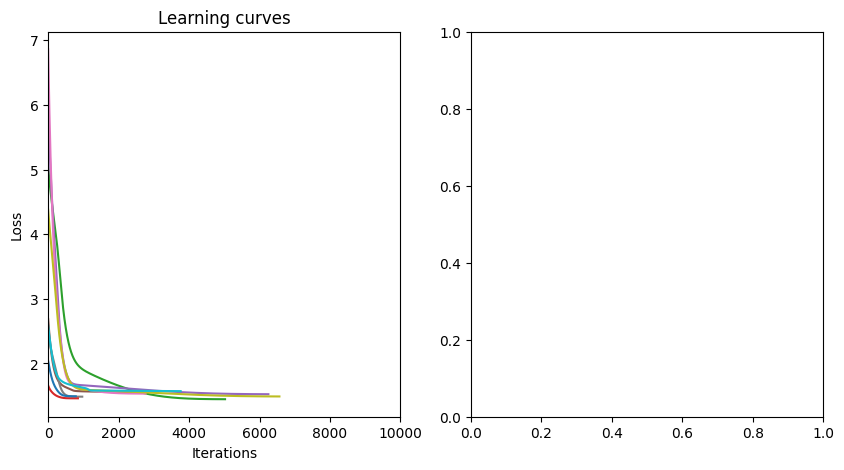

In [30]:
# Step 1: Set up outer cross-validation
K1 = 10  # outer folds
K2 = 5 # inner folds

CV_outer = KFold(n_splits=K1, shuffle=True, random_state=42)

# Define candidate values for number of hidden units
hidden_units_candidates = [1, 2, 4, 8, 16]

folds = list(CV_outer.split(X_scaled))

# Set device to CUDA if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Convert targets to tensor (as float for regression)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).squeeze().to(device)
Y_tensor = torch.tensor(y, dtype=torch.float32).squeeze().to(device)

max_iter = 10000
n_replicates = 1   # number of networks trained in each k-fold. Gets passed in the model 

loss_fn = torch.nn.MSELoss()  # notice how this is now a mean-squared-error loss

# List storing gen_errors in each outer loop
ANN_errors = []  
n_hidden_layer_error = np.zeros((K1, len(hidden_units_candidates)))
best_n_hidden_neurons = []


# Setup figure for display of learning curves and error rates in fold
summaries, summaries_axes = plt.subplots(1, 2, figsize=(10, 5))
# Make a list for storing assigned color of learning curve for up to K=10
color_list = [
    "tab:orange",
    "tab:green",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
    "tab:red",
    "tab:blue",
]

# ANN

# outer loop
for outer_fold_idx, (outer_train_index, outer_test_index) in enumerate(folds, start=1):
    print("\nOutter crossvalidation fold: {0}/{1}".format(outer_fold_idx + 1, K1))
    X_train_outer_tensor, X_test_outer_tensor = X_tensor[outer_train_index], X_tensor[outer_test_index]
    Y_train_outer_tensor, Y_test_outer_tensor = Y_tensor[outer_train_index], Y_tensor[outer_test_index]

    CV_inner = KFold(n_splits=K2, shuffle=True, random_state=42)

    inner_folds = list(CV_inner.split(X_train_outer_tensor))

    for inner_fold_idx, (inner_train_index, validation_index) in enumerate(inner_folds, start=1):
        print("\nInner crossvalidation fold: {0}/{1}".format(inner_fold_idx + 1, K2))
        X_train_inner_tensor, X_validate_tensor = X_tensor[inner_train_index], X_tensor[validation_index]
        Y_train_inner_tensor, Y_validate_tensor = Y_tensor[inner_train_index], Y_tensor[validation_index]


        
        # Different number of hidden units in hidden layer 
        for n_hidden_neuron in hidden_units_candidates:
            print(f"{n_hidden_neuron} hidden layer")
            # Define the model
            model = lambda: torch.nn.Sequential(
            torch.nn.Linear(M, n_hidden_neuron),
            torch.nn.Tanh(),
            torch.nn.Linear(n_hidden_neuron, 1)
            )

            # Train network on our the inner training data 
            net, final_loss, learning_curve = train_neural_net(     #network(net) is the trained neural network. Takes the 20 attribute as input and outputs its estimate of the heart disease
                model,
                loss_fn,
                X=X_train_inner_tensor,
                y=Y_train_inner_tensor,
                n_replicates=n_replicates,
                max_iter=max_iter,
            )


            # Determine estimated class labels for test set
            y_validate_estimate = net(X_validate_tensor)
        
            # Determine the test error for the specifik amount of hidden layers in the inner fold using MSE
            squared_error = (y_validate_estimate.float() - Y_validate_tensor.float()) ** 2  # squared error
            mse = (sum(squared_error).type(torch.float) / len(Y_validate_tensor)).mean() #.data.numpy()  # mean
            n_hidden_layer_error[outer_fold_idx,hidden_units_candidates.index(n_hidden_neuron)] += mse.item()/K1


    # ANN: Trains neural network on the test set in the  outer fold 
    # Uses the optimal number of hidden units/neurons found in the inner validation  
    n_hidden_neuron = hidden_units_candidates[np.argmin(n_hidden_layer_error[outer_fold_idx])] # finds the smallest error and uses the number of hidden units/neurons from there
    best_n_hidden_neurons.append(n_hidden_neuron) # adds to the list (to be printed in document)

    model = lambda: torch.nn.Sequential(
    torch.nn.Linear(M, n_hidden_neuron), 
    torch.nn.Tanh(),
    torch.nn.Linear(n_hidden_neuron, 1)
    )

    # Train the net on training data
    net, final_loss, learning_curve = train_neural_net(   
        model,
        loss_fn,
        X=X_train_outer_tensor,
        y=Y_train_outer_tensor,
        n_replicates=n_replicates,
        max_iter=max_iter,
        )

    # Determine estimated class labels for test set. 
    y_test_estimate = net(X_test_outer_tensor)
        
    # Determine the test error using MSE for the fold 
    squared_error = (y_test_estimate.float() - Y_test_outer_tensor.float()) ** 2  # squared error
    mse = ((y_test_estimate.float() - Y_test_outer_tensor.float()) ** 2).mean()  #mse = (sum(squared_error).type(torch.float) / len(Y_test_outer_tensor)).data.numpy()  # mean
    ANN_errors.append(mse.item())

    # Display the learning curve for the best net in the current fold (learning curves)
    (h,) = summaries_axes[0].plot(learning_curve, color=color_list[outer_fold_idx])
    h.set_label("CV fold {0}".format(outer_fold_idx + 1))
    summaries_axes[0].set_xlabel("Iterations")
    summaries_axes[0].set_xlim((0, max_iter))
    summaries_axes[0].set_ylabel("Loss")
    summaries_axes[0].set_title("Learning curves")


print("ANN errors:",ANN_errors, "with respectively", best_n_hidden_neurons, "number of hidden layers")

#Neural Network Plots

# Display the MSE across folds (block diagram)
summaries_axes[1].bar(
    np.arange(1, K1 + 1), np.squeeze(np.asarray(ANN_errors)), color=color_list
)
summaries_axes[1].set_xlabel("Fold")
summaries_axes[1].set_xticks(np.arange(1, K1 + 1))
summaries_axes[1].set_ylabel("MSE")
summaries_axes[1].set_title("Test mean-squared-error")


# Netværk
print("Diagram of best neural net in last fold:")
weights = [net[i].weight.data.numpy().T for i in [0, 2]]
biases = [net[i].bias.data.numpy() for i in [0, 2]]
tf = [str(net[i]) for i in [1, 2]]
draw_neural_net(weights, biases, tf, attribute_names=attributeNames.tolist())
